<a href="https://colab.research.google.com/github/vixlima/neural-networks/blob/main/Classificar_o_MNIST_original.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Classificar o MNIST original

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

In [2]:
print("Baixando o dataset original do MNIST via OpenML...")
mnist = fetch_openml('mnist_784', version=1, cache=True, parser='auto')

Baixando o dataset original do MNIST via OpenML (pode levar 1-2 minutos)...


In [3]:
X_raw = mnist.data.to_numpy().astype('float32')
y_raw = mnist.target.to_numpy().astype('int64')

In [4]:
X_images = X_raw.reshape(-1, 28, 28)

In [5]:
train_images, test_images, train_labels, test_labels = train_test_split(
    X_images, y_raw, test_size=10000, random_state=42
)

In [6]:
print("Imagens de Treino:", train_images.shape)
print("Labels de Treino:", train_labels.shape)
print("Imagens de Teste:", test_images.shape)
print("Labels de Teste:", test_labels.shape)

Imagens de Treino: (60000, 28, 28)
Labels de Treino: (60000,)
Imagens de Teste: (10000, 28, 28)
Labels de Teste: (10000,)


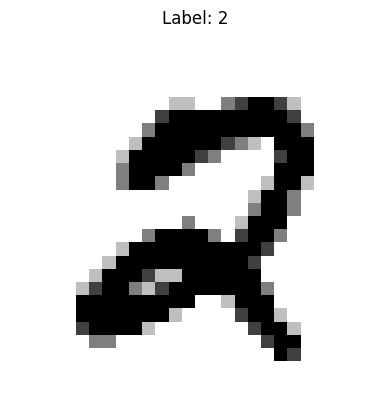

In [7]:
plt.imshow(train_images[0], cmap=plt.cm.binary)
plt.title(f"Label: {train_labels[0]}")
plt.axis('off')
plt.show()

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [9]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device selecionado:", device)

Device selecionado: cpu


In [10]:
class TorchCNN2D(nn.Module):
    def __init__(self, input_shape, output_shape):
        super(TorchCNN2D, self).__init__()
        # input_shape para imagens PyTorch é (Canais, Altura, Largura) -> (1, 28, 28)
        self.conv1 = nn.Conv2d(in_channels=input_shape[0], out_channels=32, kernel_size=3)
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3)
        self.flatten = nn.Flatten()

        # Após 3 convoluções e 2 MaxPoolings de uma imagem 28x28, sobram 1152 features
        self.fc = nn.Linear(in_features=1152, out_features=output_shape)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = F.relu(self.conv3(x))
        x = self.flatten(x)
        x = self.fc(x)
        # O professor inclui o softmax no final da rede no PyTorch
        x = F.softmax(x, dim=1)
        return x

In [11]:
model_teste = TorchCNN2D((1, 28, 28), 10)
print(model_teste)

TorchCNN2D(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=1152, out_features=10, bias=True)
)


In [12]:
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

In [13]:
class TorchWrappedNN(BaseEstimator, ClassifierMixin):
    def __init__(self, epochs=5, batch_size=128, model_fabric=TorchCNN2D):
        self.epochs = epochs
        self.batch_size = batch_size
        self.model_fabric = model_fabric

    def fit(self, X, y):
        # Correção do warning do torch sobre recriar tensores já existentes
        self.labels, ids = torch.unique(torch.as_tensor(y), return_inverse=True)

        # X.shape[1:] captura a entrada como (1, 28, 28) graças ao transformer Shape2Torch
        self.model = self.model_fabric(X.shape[1:], len(self.labels)).to(device)
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.RMSprop(self.model.parameters(), lr=0.001)

        # Montando o dataset
        train_dataset = TensorDataset(
            torch.as_tensor(X, dtype=torch.float32),
            torch.as_tensor(ids, dtype=torch.long)
        )
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size)

        # Loop de Treinamento
        for epoch in range(self.epochs):
            for data in train_loader:
                inputs, labels_batch = data
                inputs, labels_batch = inputs.to(device), labels_batch.to(device)

                self.optimizer.zero_grad()
                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels_batch)
                loss.backward()
                self.optimizer.step()

            print(f"Epoch {epoch+1}/{self.epochs} concluída. Loss: {loss.item():.4f}")

        return self

    def predict(self, X):
        with torch.no_grad():
            inputs = torch.as_tensor(X, dtype=torch.float32).to(device)
            outputs = self.model(inputs)
            # Retorna o rótulo da classe com maior probabilidade
            return self.labels[torch.argmax(outputs, dim=1).cpu().numpy()].numpy()

In [14]:
class Divide255(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X / 255.0

In [15]:
class Shape2Torch(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        # PyTorch espera (N_samples, Canais, Altura, Largura) -> (-1, 1, 28, 28)
        return X.reshape((-1, 1, 28, 28))

In [16]:
print("Iniciando Pipeline...")
pipeline = Pipeline([
    ("scaler", Divide255()),         # Normaliza pra 0-1
    ("shape2Torch", Shape2Torch()),  # Ajusta o shape para convolução PyTorch
    ("model", TorchWrappedNN(epochs=5)) # Treina a CNN
])

Iniciando Pipeline...


In [17]:
print("Treinando a CNN...")
pipeline.fit(train_images, train_labels)

Treinando a CNN...
Epoch 1/5 concluída. Loss: 1.4905
Epoch 2/5 concluída. Loss: 1.4817
Epoch 3/5 concluída. Loss: 1.4617
Epoch 4/5 concluída. Loss: 1.4680
Epoch 5/5 concluída. Loss: 1.4613


Pipeline(steps=[('scaler', Divide255()), ('shape2Torch', Shape2Torch()),
                ('model', TorchWrappedNN())])

In [18]:
print("Realizando predições na base de teste...")
y_pred = pipeline.predict(test_images)
acuracia = accuracy_score(test_labels, y_pred)

print(f"\nAcurácia da CNN PyTorch no MNIST Original (OpenML): {acuracia * 100:.2f}%")

Realizando predições na base de teste...

Acurácia da CNN PyTorch no MNIST Original (OpenML): 98.72%


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [19]:
import numpy as np
import matplotlib.pyplot as plt

In [20]:
num_amostras = 9

In [21]:
# Sorteando índices aleatórios da base de teste
indices_aleatorios = np.random.randint(0, len(test_images), num_amostras)

In [22]:
amostras_imagens = test_images[indices_aleatorios]
rotulos_reais = test_labels[indices_aleatorios]

In [23]:
rotulos_preditos = pipeline.predict(amostras_imagens)

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [24]:
plt.figure(figsize=(10, 10))

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

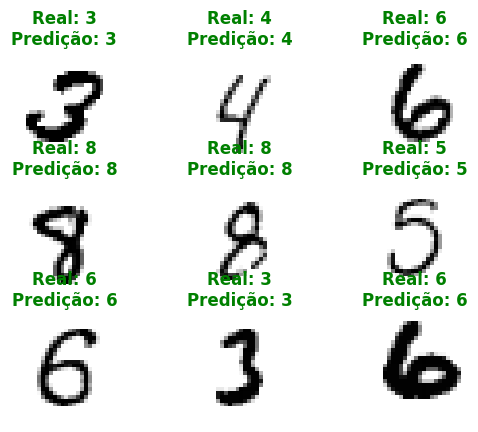

In [26]:
for i in range(num_amostras):
    plt.subplot(3, 3, i + 1)

    plt.imshow(amostras_imagens[i], cmap=plt.cm.binary)

    cor_texto = 'green' if rotulos_preditos[i] == rotulos_reais[i] else 'red'

    plt.title(f"Real: {rotulos_reais[i]}\nPredição: {rotulos_preditos[i]}", color=cor_texto, fontweight='bold')

    plt.axis('off')

In [27]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>